## Pseudocode

```text
Input: X ∈ R^(C×T), sampling rate fs
Output: I_stack

1. t ← [0, 1, ..., T-1] / fs
2. panels ← []
3. for c = 1 to C:
       plot X[c, :] against t as one standalone waveform panel
       remove ticks and spines
       export panel as RGB image P_c
       append P_c to panels
4. I_stack ← vertically concatenate P_1, P_2, ..., P_C
5. return I_stack
```


In [9]:
import io
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

def render_vire_stack(
    X,                  # [C, T]
    fs=256,
    panel_width=1400,
    per_panel_height=120,
    dpi=50,
    line_px=6.0,
    cmap_name="tab20",
):
    C, T = X.shape
    t = np.arange(T, dtype=np.float32) / float(fs)
    cmap = plt.get_cmap(cmap_name, C)
    colors = [cmap(i) for i in range(C)]
    linewidth_pt = max(0.5, line_px) * 72.0 / dpi

    panels = []
    for c in range(C):
        fig = plt.figure(figsize=(panel_width / dpi, per_panel_height / dpi), dpi=dpi)
        ax = fig.add_subplot(111)
        ax.plot(t, X[c], color=colors[c], linewidth=linewidth_pt)
        ax.set_xlim(float(t[0]), float(t[-1]))
        ax.set_xticks([])
        ax.set_yticks([])
        for side in ("top", "right", "left", "bottom"):
            ax.spines[side].set_visible(False)
        plt.tight_layout(pad=0.1)

        buf = io.BytesIO()
        fig.savefig(buf, format="png", dpi=dpi)   # no bbox_inches='tight'
        plt.close(fig)
        buf.seek(0)
        panels.append(Image.open(buf).convert("RGB"))

    w = panels[0].size[0]
    total_h = sum(im.size[1] for im in panels)
    I_stack = Image.new("RGB", (w, total_h), (255, 255, 255))

    y = 0
    for im in panels:
        I_stack.paste(im, (0, y))
        y += im.size[1]

    return I_stack


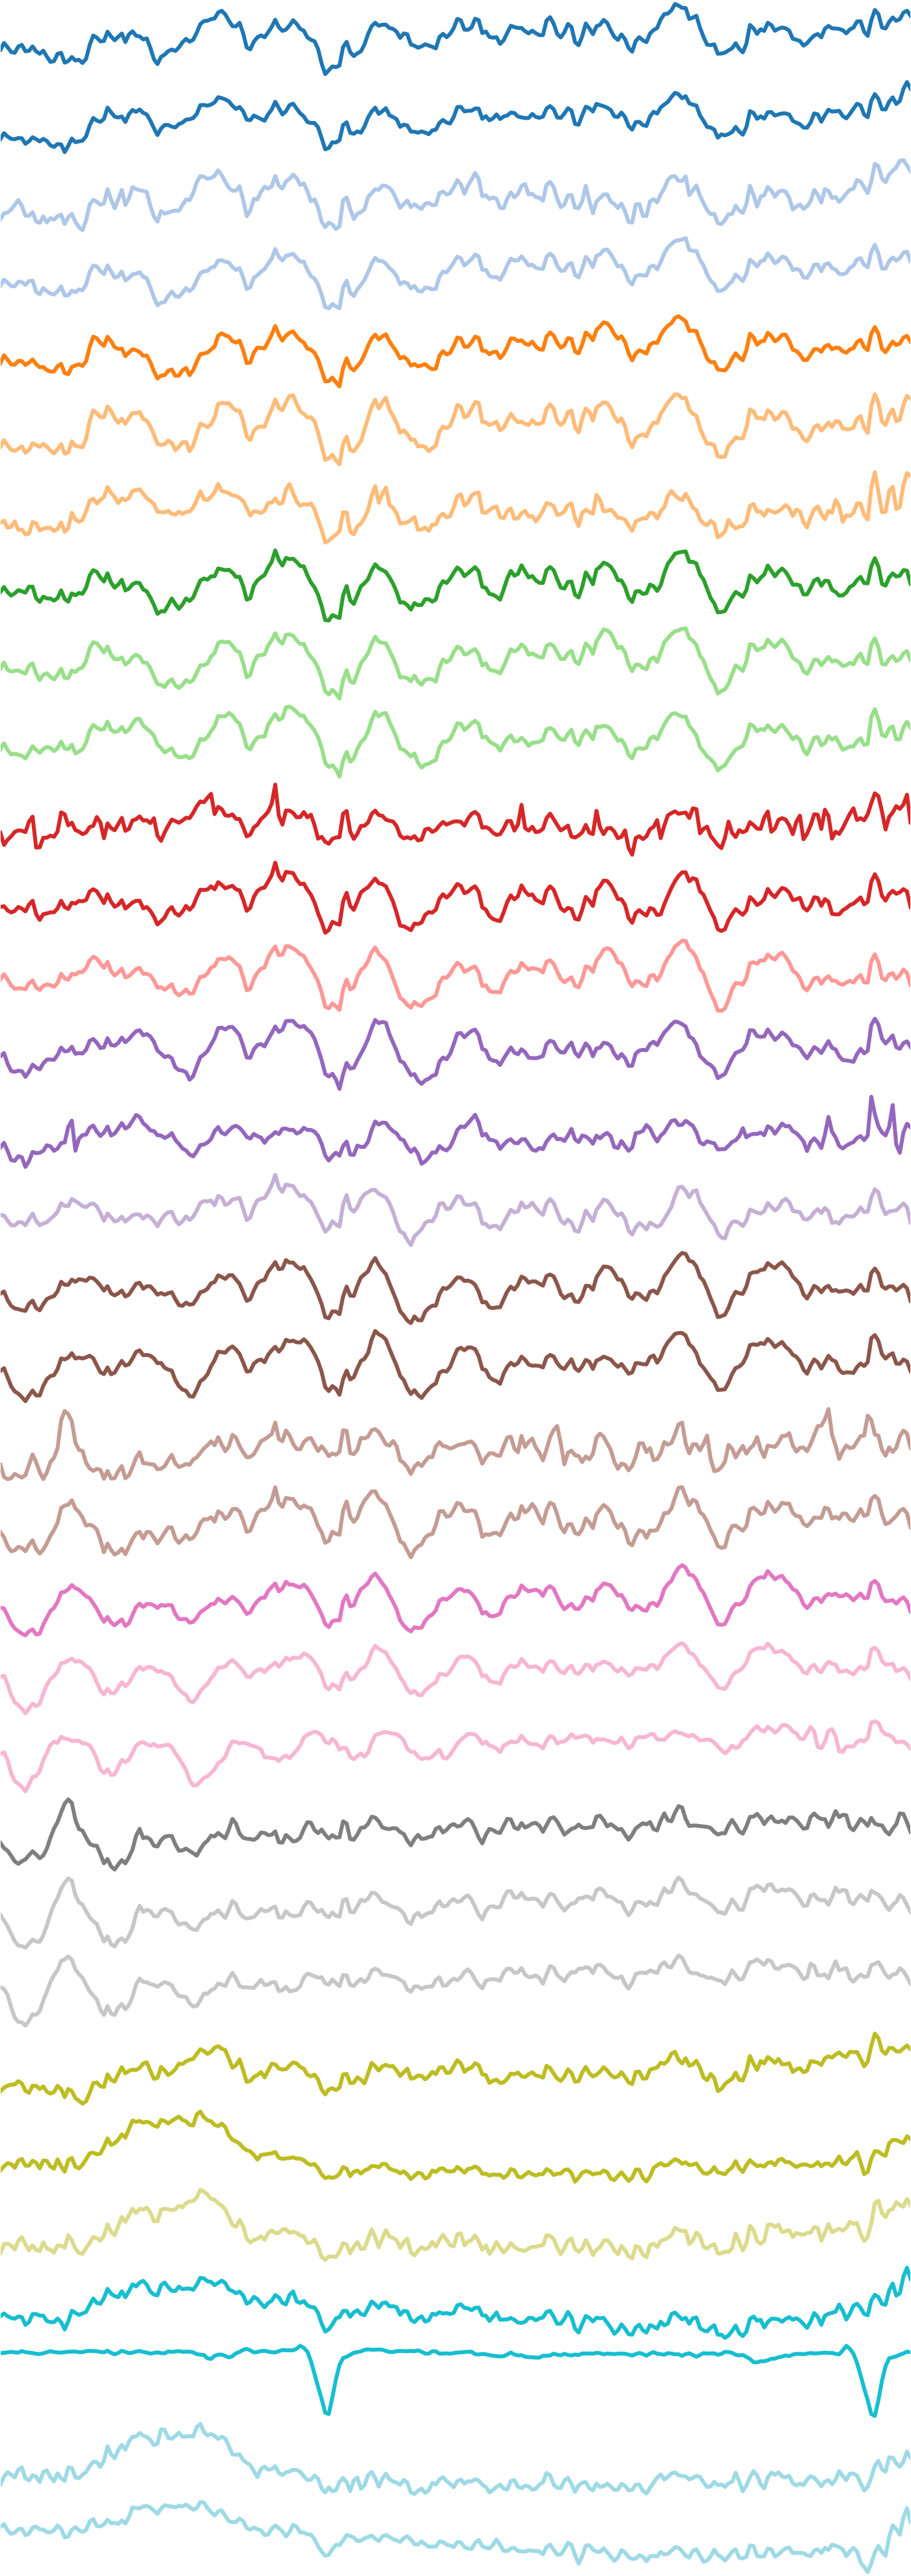

In [10]:
arr = np.load(r"C:\Download\Download_Google\Data\Med\TDBrain\TDBrain\Feature\feature_08.npy", allow_pickle=True)   # [N, T, C_all]
X_tc = arr[8, :, :].astype(np.float32)   # [T, 33]
X = X_tc.T                                # [33, T]

img = render_vire_stack(X, fs=250)
display(img)
